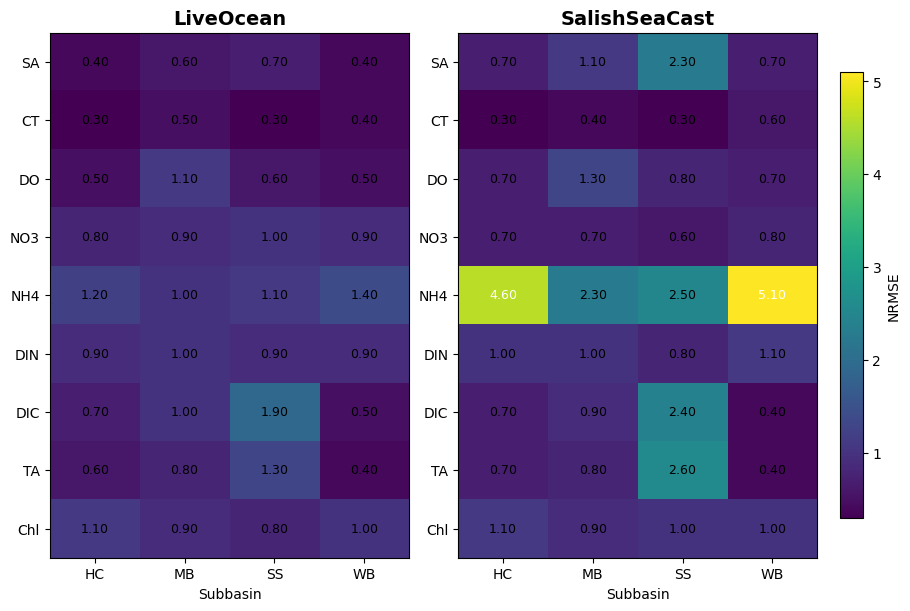

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

variables = ['SA','CT','DO','NO3','NH4','DIN','DIC','TA','Chl']
basins = ['HC','MB','SS','WB']

# 2014 comparison of RMSE for LiveOcean and SalishSeaCast models

rmse_lo = np.array([
    [1.2,0.8,0.7,1.8],   # SA
    [0.8,0.8,0.9,0.8],   # CT
    [1.6,1.1,1.2,1.4],   # DO
    [9.1,6.1,8.2,7.8],   # NO3
    [1.3,1.3,1.5,1.2],   # NH4
    [9.5,6.2,7.2,7.8],   # DIN
    [96.6,74.1,80.6,74.5],   # DIC
    [43.1,36.7,30.2,44.5],   # TA
    [6.6,6.7,8.0,17.4],   # Chl
])

rmse_ssc = np.array([
    [1.9,1.5,2.4,3.2],
    [1.1,1.1,0.8,1.2],
    [2.1,1.3,1.5,2.0],
    [7.8,4.6,5.1,7.3],
    [4.9,2.9,3.4,4.4],
    [11.0,6.2,6.5,9.8],
    [97.9,62.6,104.1,82.6],
    [48.6,33.7,60.7,48.4],
    [6.9,7.0,9.7,17.5],
])

nrmse_lo = np.array([
    [0.5,0.4,0.3,0.8],   # SA
    [0.3,0.3,0.3,0.3],   # CT
    [0.7,0.5,0.5,0.6],   # DO
    [1.1,0.7,1.0,0.9],   # NO3
    [1.0,1.0,1.2,0.9],   # NH4
    [1.3,0.8,1.0,1.1],   # DIN
    [0.9,0.7,0.7,0.8],   # DIC
    [0.6,0.5,0.4,0.6],   # TA
    [0.8,0.8,1.0,2.2],   # Chl
])

nrmse_ssc = np.array([
    [0.8,0.7,1.1,1.4],
    [0.4,0.4,0.3,0.5],
    [0.9,0.6,0.6,0.9],
    [1.0,2.3,0.6,0.9],
    [3.8,0.8,2.6,3.4],
    [1.5,1.0,0.9,1.3],
    [0.9,0.6,1.0,0.7],
    [0.7,0.5,0.9,0.7],
    [0.9,0.9,1.2,2.2],
])

# ----------------------------
# Plot
# ----------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(9,6),
    constrained_layout=True
)

# Use the same color scale for both models
vmin = min(nrmse_lo.min(), nrmse_ssc.min())
vmax = max(nrmse_lo.max(), nrmse_ssc.max())

titles = ['LiveOcean', 'SalishSeaCast']
datasets = [nrmse_lo, nrmse_ssc]

for ax, data, title in zip(axes, datasets, titles):

    im = ax.imshow(
        data,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        aspect='auto'
    )

    ax.set_title(title, fontsize=14, fontweight='bold')

    ax.set_xticks(np.arange(len(basins)))
    ax.set_xticklabels(basins)

    ax.set_yticks(np.arange(len(variables)))
    ax.set_yticklabels(variables)

    ax.set_xlabel('Subbasin')

    # write RMSE values inside cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):

            color = 'white'
            if data[i,j] < (vmin + vmax)/2:
                color = 'black'

            ax.text(
                j,
                i,
                f'{data[i,j]:.2f}',
                ha='center',
                va='center',
                fontsize=9,
                color=color
            )

# One shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85,
    pad=0.03
)

cbar.set_label('NRMSE')

plt.show()